Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]
(7, 3)
[601.8873   601.8873   601.8873   347.334468 474.610884 856.440132
 729.163716]
[395.23776 289.17408 236.14224 395.23776 289.17408 395.23776 289.17408]


<function matplotlib.pyplot.show(close=None, block=None)>

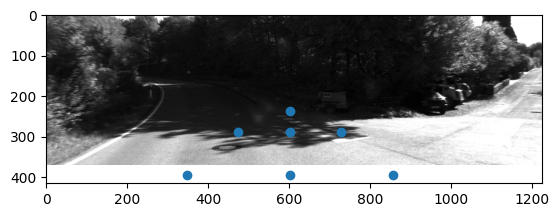

In [34]:
#2번 projection matrix를 이용하여 이미지에 좌표에 투영
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

#step1
calib= {}


with open('/content/drive/MyDrive/09/calib.txt','r') as f:
  for line in f:
    key, values= line.split (':',1)
    calib[key.strip()] = np.array([float(v) for v in values.split()])

P0 = calib['P0'].reshape(3,4)
print(P0)


points_3d = np.array([
    [0, 1.5, 5],
    [0, 1.5, 10],
    [0, 1.5, 20],
    [-1.8, 1.5, 5],
    [-1.8, 1.5, 10],
    [1.8, 1.5, 5],
    [1.8, 1.5, 10],
])

print(points_3d.shape)

#step2
def project(points_3d, P) :

  ones=np.ones((len(points_3d), 1))
  points_h= np.hstack ([points_3d, ones])

  projected = (P@ points_h.T).T

  u = projected[:,0] / projected [:,2]
  v= projected[:,1] / projected[:,2]

  return u, v

u, v= project (points_3d, P0)
print (u)
print (v)

#step3

from PIL import Image
import matplotlib.pyplot as plt

img =np.array(Image.open('/content/drive/MyDrive/09/image_0/000000.png'))


plt.imshow(img, cmap='gray')
plt.scatter (u,v)
plt.show

(1591, 3)
[5.551115e-17 0.000000e+00 2.220446e-16]
[0. 0. 0.]


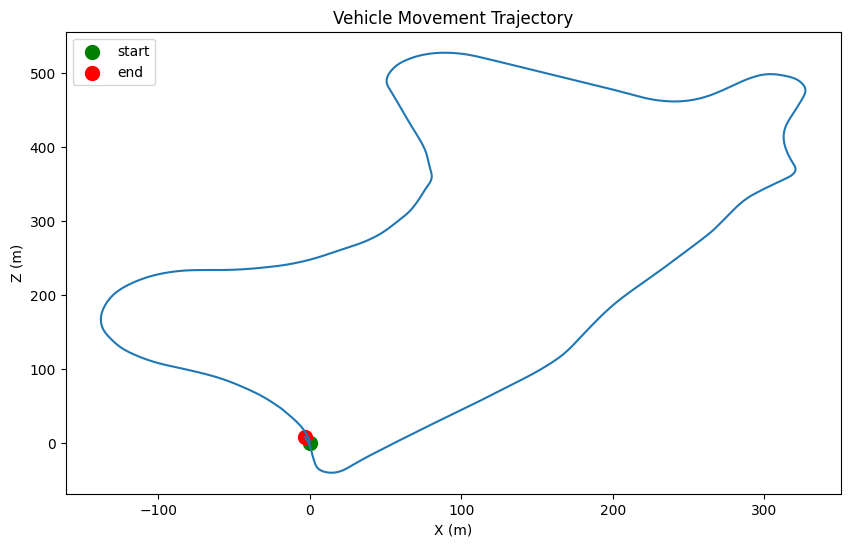

In [35]:
#3번 차량 이동 궤적

positions=[]

with open('/content/drive/MyDrive/09/poses.txt', 'r') as f:
    for line in f:
      vals= np.array([float(v) for v in line.split()])
      T = vals.reshape(3, 4)
      t = T[:, 3]

      positions.append(t)

positions=np.array(positions)

print(positions.shape)
print(positions[0])

positions = positions - positions[0]
print(positions[0])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(positions[:, 0], positions[:, 2])  # x, z 평면
plt.scatter(positions[0, 0], positions[0, 2], c='green', s=100, label='start')
plt.scatter(positions[-1, 0], positions[-1, 2], c='red', s=100, label='end')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Vehicle Movement Trajectory')
plt.legend()
plt.show()

Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency
Processed 000010 with temporal consistency
Processed 000011 with temporal consistency
Processed 000012 with temporal consistency
Processed 000013 with temporal consistency
Processed 000014 with temporal consistency
Processed 000015 with temporal consistency
Processed 000016 with temporal consistency
Processed 000017 with temporal consistency
Processed 000018 with temporal consistency
Processed 000019 with temporal consistency
Processed 000020 with temporal consistency
Processed 000021 with temporal consistency
Processed 000022 with temporal consistency
Processed 0

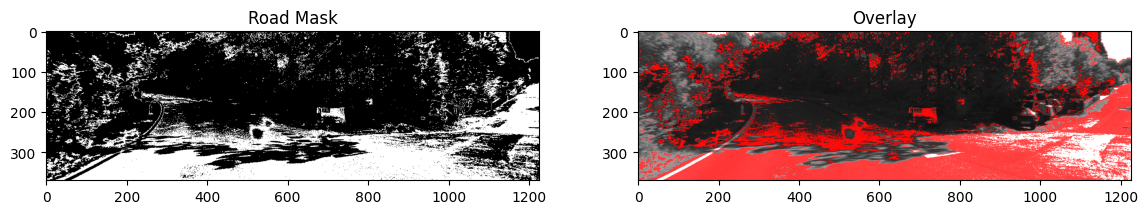

도로 픽셀 수: 136656
유효한 점 수: 111244


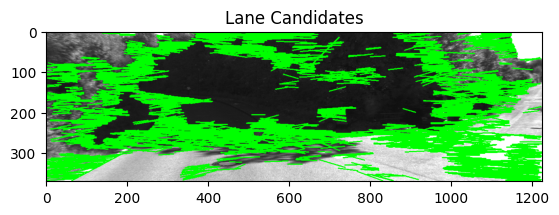

In [36]:
#4번 Projection Matrix를 활용한 차선 해석

#!/usr/bin/env python3
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):

    mask = np.zeros((height, width), dtype=np.uint8)

    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)

    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]

    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):

    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape

    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주

    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)

        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)

        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)

        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

run(
    data_root=Path('/content/drive/MyDrive/09/image_0'),
    train_frames=80,
    save_frames=30,
    out_dir=Path('/content/outputs/bayes_road'),
    prior_road=0.5,
)

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

mask = np.array(Image.open('/content/outputs/bayes_road/mask_000000.png'))
overlay = np.array(Image.open('/content/outputs/bayes_road/overlay_000000.png'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Road Mask')
axes[1].imshow(overlay)
axes[1].set_title('Overlay')
plt.show()

# 마스크에서 도로 픽셀 위치 꺼내기
road_pixels = np.where(mask == 255)
v_coords = road_pixels[0]  # 행 = v
u_coords = road_pixels[1]  # 열 = u

print(f'도로 픽셀 수: {len(u_coords)}')

# 역투영 함수
def back_project(u, v, P0, Y=1.5):
    fx = P0[0, 0]
    fy = P0[1, 1]
    cx = P0[0, 2]
    cy = P0[1, 2]

    Z = fy * Y / (v - cy)
    X = (u - cx) * Z / fx

    return X, Z

# 역투영 실행
X_coords, Z_coords = back_project(u_coords, v_coords, P0)

# Z > 0 인 것만 (카메라 앞쪽)
valid = Z_coords > 0
X_coords = X_coords[valid]
Z_coords = Z_coords[valid]

print(f'유효한 점 수: {len(X_coords)}')
import cv2

# 엣지 검출
edges = cv2.Canny(mask, 50, 150)

# Hough Transform으로 선 찾기
lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                         threshold=50,
                         minLineLength=30,
                         maxLineGap=20)

# 원본 이미지 위에 선 그리기
img = np.array(Image.open('/content/drive/MyDrive/09/image_0/000000.png'))
img_color = np.stack([img, img, img], axis=-1)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_color, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(img_color)
plt.title('Lane Candidates')
plt.show()

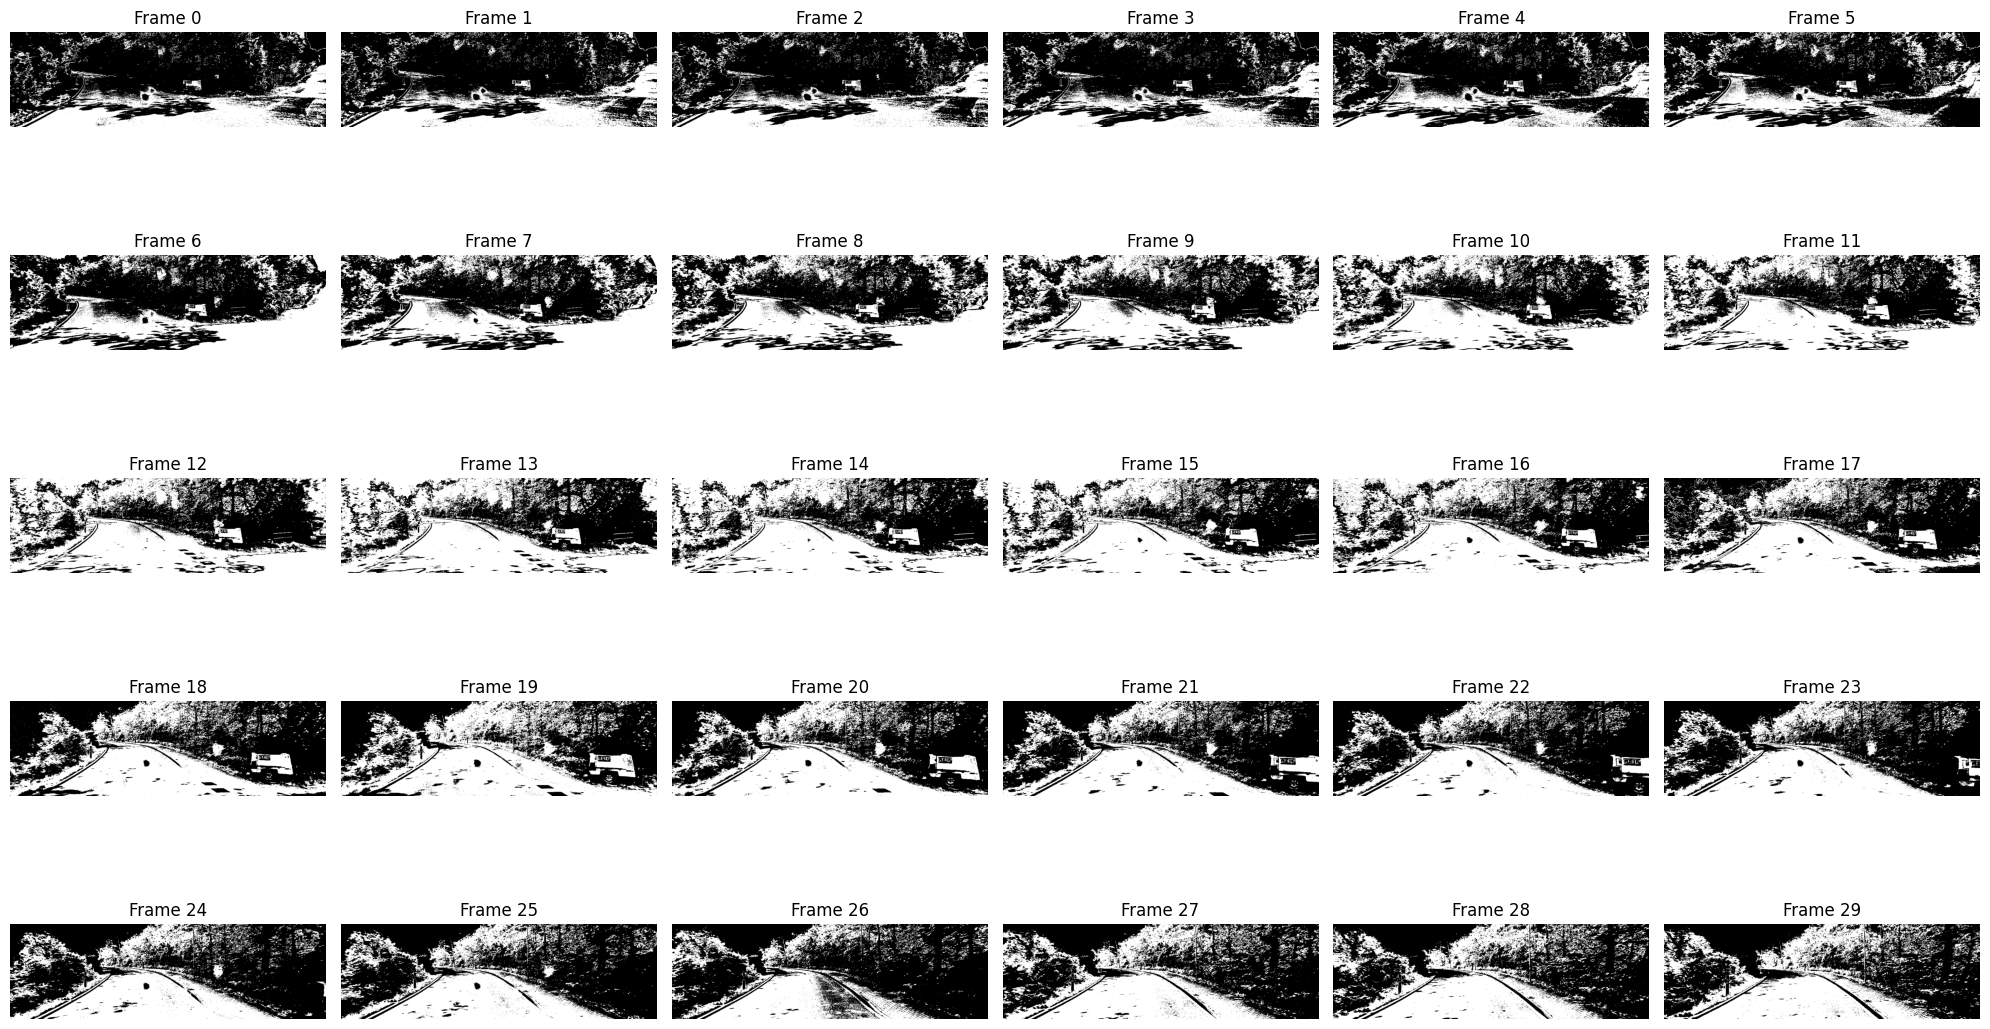

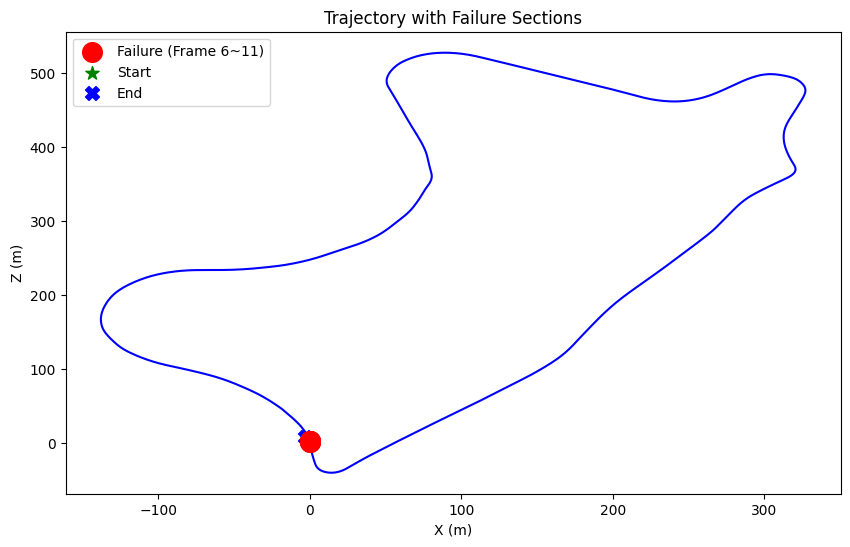

In [37]:
fig, axes = plt.subplots(5, 6, figsize=(20, 12))

for i, ax in enumerate(axes.flatten()):
    mask_path = f'/content/outputs/bayes_road/mask_{str(i).zfill(6)}.png'
    mask_img = np.array(Image.open(mask_path))
    ax.imshow(mask_img, cmap='gray')
    ax.set_title(f'Frame {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(positions[:, 0], positions[:, 2], 'b-')

# 실패 구간 (Frame 6~11) 빨간점으로 표시
plt.scatter(positions[6:12, 0], positions[6:12, 2],
            c='red', s=200, zorder=5, label='Failure (Frame 6~11)')

plt.scatter(positions[0, 0], positions[0, 2], c='green', s=100, marker='*', label='Start')
plt.scatter(positions[-1, 0], positions[-1, 2], c='blue', s=100, marker='X', label='End')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Trajectory with Failure Sections')
plt.legend()
plt.show()

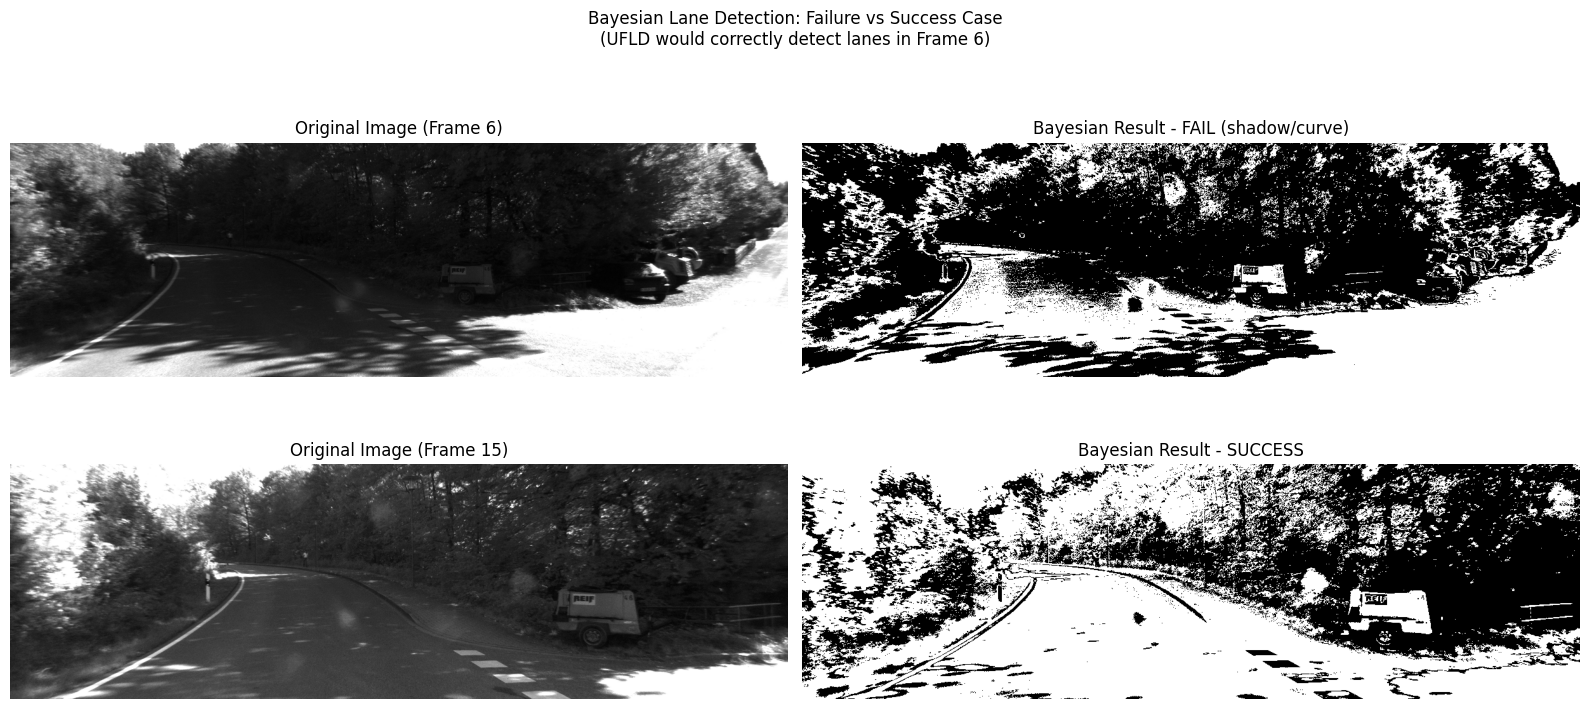

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# (1) 원본
img6 = np.array(Image.open('/content/drive/MyDrive/09/image_0/000006.png'))
axes[0,0].imshow(img6, cmap='gray')
axes[0,0].set_title('Original Image (Frame 6)')
axes[0,0].axis('off')

# (2) Bayesian 실패
mask6 = np.array(Image.open('/content/outputs/bayes_road/mask_000006.png'))
axes[0,1].imshow(mask6, cmap='gray')
axes[0,1].set_title('Bayesian Result - FAIL (shadow/curve)')
axes[0,1].axis('off')

# (3) Bayesian 성공
img15 = np.array(Image.open('/content/drive/MyDrive/09/image_0/000015.png'))
axes[1,0].imshow(img15, cmap='gray')
axes[1,0].set_title('Original Image (Frame 15)')
axes[1,0].axis('off')

# (4) Bayesian 성공 마스크
mask15 = np.array(Image.open('/content/outputs/bayes_road/mask_000015.png'))
axes[1,1].imshow(mask15, cmap='gray')
axes[1,1].set_title('Bayesian Result - SUCCESS')
axes[1,1].axis('off')

plt.suptitle('Bayesian Lane Detection: Failure vs Success Case\n(UFLD would correctly detect lanes in Frame 6)',
             fontsize=12)
plt.tight_layout()
plt.show()